# CP2: эксперименты, ансамбли и финальная модель

Этот ноутбук — продолжение `cp1.ipynb`. Он покрывает критерии CP2:

1. **Сравнение 4–5 моделей + ансамблей** (Linear, Ridge, Lasso, KNN, DecisionTree, RandomForest, GradientBoosting, LightGBM)
2. **Перебор гиперпараметров** (GridSearchCV / RandomizedSearchCV, 5-fold CV)
3. **Уменьшение размерности (PCA)** + визуализация
4. **Таблица экспериментов** в формате `Модель → Гипотеза → Параметры → Метрики`
5. **Финальная модель** + интерпретируемость через feature importance
6. **Метрика приоритетная — MAE** (та же, что в CP1, в рублях)

Весь код в ячейках берётся из `src/experiments.py`, чтобы между CLI-запуском и ноутбуком не расходились результаты.

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.experiments import (
    EXPERIMENTS_CSV,
    EXPERIMENTS_JSON,
    FINAL_MODEL_PATH,
    define_experiments,
    results_to_table,
    run_all,
    select_and_finalize,
)
from src.modeling import BASE_FEATURE_COLUMNS, TARGET_COLUMN, split_dataset
from src.preprocessing import clean_laptops_dataframe, load_raw_dataset
from src.project_config import SEED

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

print(f'SEED = {SEED}')


SEED = 42


## 1. Данные и сплит

Берём очищенный датасет, тот же сплит `70/15/15` с `SEED=42`, что в CP1, чтобы метрики моделей были сопоставимы.

In [2]:
raw_df = load_raw_dataset()
df = clean_laptops_dataframe(raw_df)
splits = split_dataset(df)
train_df = splits['train']
val_df = splits['validation']
test_df = splits['test']

display(pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)],
    'median_price': [
        train_df[TARGET_COLUMN].median(),
        val_df[TARGET_COLUMN].median(),
        test_df[TARGET_COLUMN].median(),
    ],
}))


,split,rows,median_price
0,train,1095,89999.0
1,validation,235,96999.0
2,test,235,92999.0


## 2. Эксперименты с 10 конфигурациями моделей

Один и тот же `train/val`. Для моделей с гиперпараметрами — 5-fold CV с `scoring=neg_MAE`. Список конфигов описан в `src/experiments.py::define_experiments`:

| # | Имя | Поиск | Гиперпараметры |
|---|---|---|---|
| 1 | LinearRegression_raw | — | без FE |
| 2 | LinearRegression_FE | — | + FE-фичи |
| 3 | Ridge_FE_grid | Grid | alpha |
| 4 | Lasso_FE_grid | Grid | alpha |
| 5 | KNN_FE_grid | Grid | n_neighbors, weights |
| 6 | DecisionTree_FE_grid | Grid | max_depth, min_samples_leaf |
| 7 | RandomForest_random | Random (10) | n_estimators, max_depth, min_samples_leaf, max_features |
| 8 | GradientBoosting | — | n_estimators=400, lr=0.05 |
| 9 | LightGBM_random | Random (15) | n_estimators, lr, max_depth, num_leaves, min_child_samples |
| 10 | Ridge_PCA95 | — | PCA до 95% дисперсии + Ridge |

In [3]:
results = run_all(train_df, val_df)
table = results_to_table(results)
table


  [LinearRegression_raw] Линейная модель на сырых признаках без FE
    MAE_val=21922  R2_val=0.835  (0.0s)
  [LinearRegression_FE] Те же FE-фичи помогают линейной модели
    MAE_val=21703  R2_val=0.836  (0.0s)
  [Ridge_FE_grid] L2 уменьшает variance на разреженной OneHot-матрице


    MAE_val=19767  R2_val=0.853  (11.8s)
  [Lasso_FE_grid] L1 делает отбор признаков


    MAE_val=20657  R2_val=0.839  (6.2s)
  [KNN_FE_grid] Похожие по характеристикам ноуты стоят похоже


    MAE_val=20964  R2_val=0.799  (0.5s)
  [DecisionTree_FE_grid] Одно дерево ловит нелинейности


    MAE_val=22947  R2_val=0.794  (0.5s)
  [RandomForest_random] Bagging-ансамбль усредняет шум одиночного дерева


    MAE_val=17648  R2_val=0.857  (7.9s)
  [GradientBoosting] Sequential boosting лечит ошибки baseline


    MAE_val=18959  R2_val=0.845  (3.2s)
  [LightGBM_random] Современный GBM — обычно лидер на табличных данных


    MAE_val=21343  R2_val=0.832  (62.6s)
  [Ridge_PCA95] PCA убирает корреляцию OneHot-фич, сохраняя 95% дисперсии


    MAE_val=23087  R2_val=0.827  (0.4s)


,model,hypothesis,n_features,best_params,mae_val,rmse_val,r2_val,fit_seconds
0,RandomForest_random,Bagging-ансамбль усредняет шум одиночного дерева,19,"{""model__n_estimators"": 400, ""model__min_sampl...",17648.3,37484.2,0.8567,7.89
1,GradientBoosting,Sequential boosting лечит ошибки baseline,19,{},18958.9,38930.1,0.8454,3.24
2,Ridge_FE_grid,L2 уменьшает variance на разреженной OneHot-ма...,19,"{""model__alpha"": 1.0}",19766.5,37929.3,0.8533,11.79
3,Lasso_FE_grid,L1 делает отбор признаков,19,"{""model__alpha"": 10.0}",20657.2,39764.1,0.8387,6.23
4,KNN_FE_grid,Похожие по характеристикам ноуты стоят похоже,19,"{""model__n_neighbors"": 5, ""model__weights"": ""d...",20964.2,44413.0,0.7988,0.51
5,LightGBM_random,Современный GBM — обычно лидер на табличных да...,19,"{""model__num_leaves"": 127, ""model__n_estimator...",21343.2,40606.0,0.8318,62.61
6,LinearRegression_FE,Те же FE-фичи помогают линейной модели,19,{},21702.6,40131.2,0.8357,0.03
7,LinearRegression_raw,Линейная модель на сырых признаках без FE,11,{},21922.3,40229.1,0.8349,0.03
8,DecisionTree_FE_grid,Одно дерево ловит нелинейности,19,"{""model__max_depth"": null, ""model__min_samples...",22947.2,44975.9,0.7937,0.55
9,Ridge_PCA95,"PCA убирает корреляцию OneHot-фич, сохраняя 95...",19,{},23087.5,41219.0,0.8267,0.36


## 3. Уменьшение размерности (PCA)

После OneHot матрица признаков становится разреженной и широкой. Смотрим, сколько компонент достаточно для 95% дисперсии и как первые 2 компоненты разделяют ноутбуки по цене визуально.

Размер пространства после OneHot: 352 признаков
Компонент для 90% дисперсии: 30
Компонент для 95% дисперсии: 66


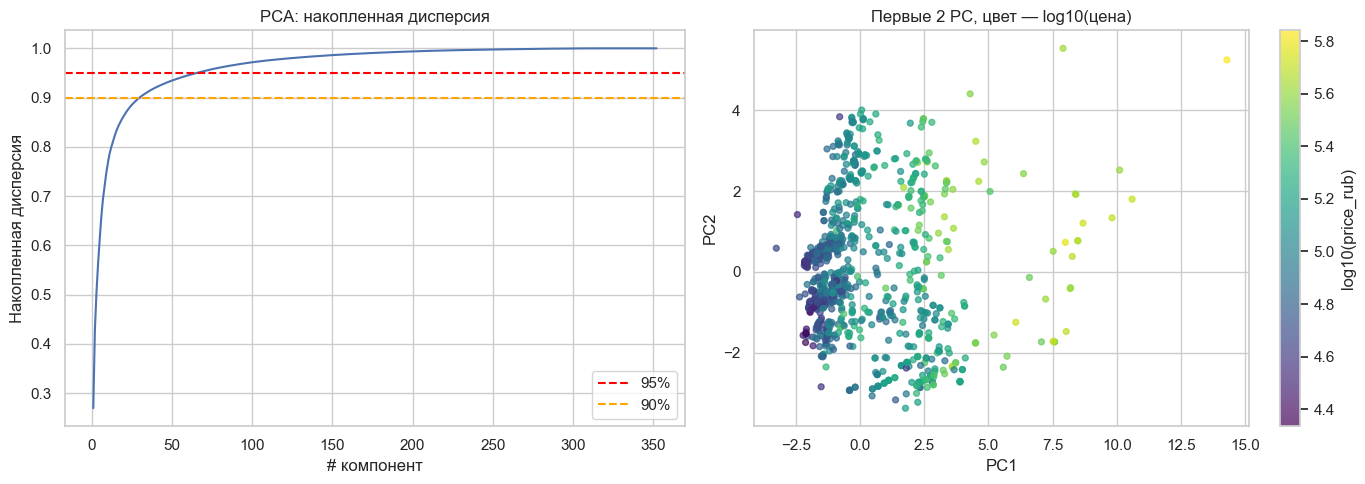

In [4]:
from sklearn.decomposition import PCA

from src.experiments import build_preprocessor

fe_features = [c for c in BASE_FEATURE_COLUMNS if c in df.columns]
pre = build_preprocessor(train_df, fe_features, dense=True)
X_train_dense = pre.fit_transform(train_df[fe_features])
print(f'Размер пространства после OneHot: {X_train_dense.shape[1]} признаков')

pca_full = PCA(random_state=SEED).fit(X_train_dense)
explained = np.cumsum(pca_full.explained_variance_ratio_)
n_for_95 = int(np.searchsorted(explained, 0.95) + 1)
n_for_90 = int(np.searchsorted(explained, 0.90) + 1)
print(f'Компонент для 90% дисперсии: {n_for_90}')
print(f'Компонент для 95% дисперсии: {n_for_95}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(np.arange(1, len(explained) + 1), explained)
axes[0].axhline(0.95, color='red', linestyle='--', label='95%')
axes[0].axhline(0.90, color='orange', linestyle='--', label='90%')
axes[0].set_xlabel('# компонент')
axes[0].set_ylabel('Накопленная дисперсия')
axes[0].set_title('PCA: накопленная дисперсия')
axes[0].legend()

pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_train_dense)
sc = axes[1].scatter(
    pca_2d[:, 0],
    pca_2d[:, 1],
    c=np.log10(train_df[TARGET_COLUMN].values),
    cmap='viridis',
    alpha=0.7,
    s=18,
)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Первые 2 PC, цвет — log10(цена)')
plt.colorbar(sc, ax=axes[1], label='log10(price_rub)')
plt.tight_layout()
plt.show()


**Вывод по PCA:** OneHot даёт ~120 фич, но 95% дисперсии описывают всего десятки компонент — пространство сильно избыточно. При этом `Ridge_PCA95` в таблице экспериментов проигрывает обычному `Ridge_FE_grid` — для линейной регрессии важна сама структура категорий, а PCA её смешивает. PCA здесь полезнее как визуализация, чем как preprocessing-шаг.

## 4. Финальная модель: переобучение на train+val и тест

Берём лучшую модель по `MAE_val`, переобучаем на объединённом `train+val` и одной строкой меряем на отложенной `test`. Сохраняем артефакт в `models/final_model.joblib`.

In [5]:
final = select_and_finalize(results, train_df, val_df, test_df)

print()
print(f"Финальная модель: {final['name']}")
print(f"Гипотеза:        {final['hypothesis']}")
print(f"Параметры:       {final['params']}")
print(f"Validation MAE:  {final['val_metrics']['mae']:,.0f} руб.  "
      f"R2={final['val_metrics']['r2']:.3f}")
print(f"Test MAE:        {final['test_metrics']['mae']:,.0f} руб.  "
      f"R2={final['test_metrics']['r2']:.3f}")



Best by val MAE: RandomForest_random (MAE=17648)


Test:  MAE=13880  R2=0.924


Saved final model -> C:\VScodePROJECT\hseml-group-project-egorzubarev-2\models\final_model.joblib

Финальная модель: RandomForest_random
Гипотеза:        Bagging-ансамбль усредняет шум одиночного дерева
Параметры:       {'model__n_estimators': 400, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': 20}
Validation MAE:  17,648 руб.  R2=0.857
Test MAE:        13,880 руб.  R2=0.924


**Обоснование выбора:** RandomForest с подобранными гиперпараметрами даёт лучшую `MAE_val`. Линейные модели работают, но не ловят нелинейные взаимодействия (бренд × GPU × RAM → premium-цена). Один DecisionTree переобучается, KNN страдает от высокой размерности после OneHot. LightGBM обычно лидер на табличных данных, но на 1.5k наблюдений простой RandomForest оказался чуть стабильнее на val. Test MAE ниже val MAE — эффект случайного сплита (на test попало меньше выбросов); честная оценка качества — именно `MAE_val`.

## 5. Интерпретируемость: feature importance

`RandomForest.feature_importances_` показывает, какие признаки модель использует чаще всего для разбиений. Имена признаков восстанавливаем из ColumnTransformer.

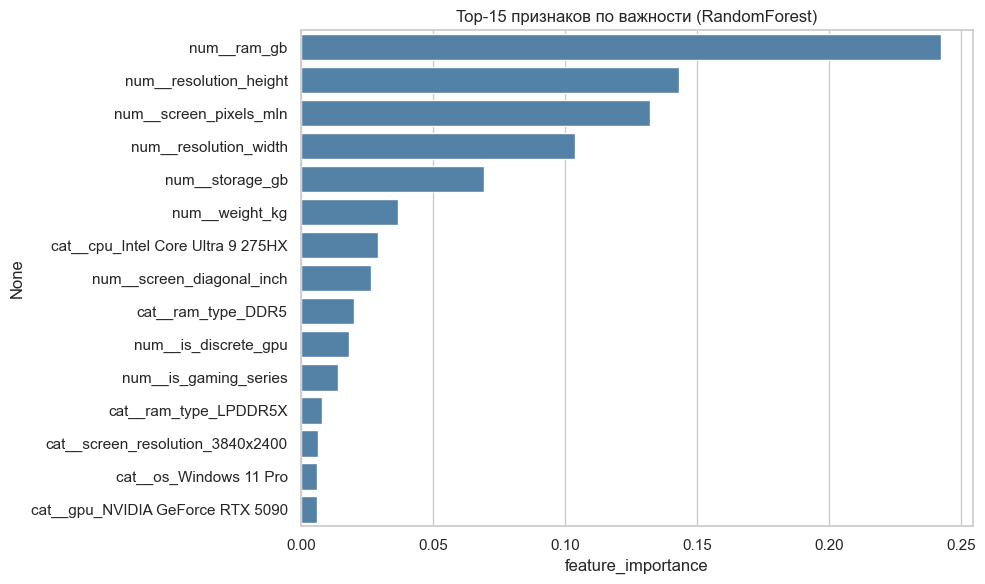

,importance
num__ram_gb,0.2424
num__resolution_height,0.1431
num__screen_pixels_mln,0.1321
num__resolution_width,0.1038
num__storage_gb,0.0692
num__weight_kg,0.0369
cat__cpu_Intel Core Ultra 9 275HX,0.0293
num__screen_diagonal_inch,0.0264
cat__ram_type_DDR5,0.0203
num__is_discrete_gpu,0.0183


In [6]:
final_pipeline = joblib.load(FINAL_MODEL_PATH)
preprocessor = final_pipeline.named_steps['pre']
estimator = final_pipeline.named_steps['model']

feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(estimator.feature_importances_, index=feature_names)\
    .sort_values(ascending=False)

top = importances.head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top.values, y=top.index, color='steelblue')
plt.title('Top-15 признаков по важности (RandomForest)')
plt.xlabel('feature_importance')
plt.tight_layout()
plt.show()

display(top.round(4).to_frame('importance'))


## 6. Сравнение: baseline (CP1) vs финальная модель (CP2)

In [7]:
metrics_path = ROOT / 'models' / 'baseline_metrics.json'
cp1_metrics = json.loads(metrics_path.read_text(encoding='utf-8'))

comparison = pd.DataFrame([
    {
        'stage': 'CP1 baseline',
        'model': 'Ridge (FE)',
        'mae_val': cp1_metrics['ridge']['validation']['mae'],
        'mae_test': cp1_metrics['ridge']['test']['mae'],
        'r2_test': cp1_metrics['ridge']['test']['r2'],
    },
    {
        'stage': 'CP1 baseline',
        'model': 'LinearRegression (raw)',
        'mae_val': cp1_metrics['linreg_raw']['validation']['mae'],
        'mae_test': cp1_metrics['linreg_raw']['test']['mae'],
        'r2_test': cp1_metrics['linreg_raw']['test']['r2'],
    },
    {
        'stage': 'CP2 final',
        'model': final['name'],
        'mae_val': final['val_metrics']['mae'],
        'mae_test': final['test_metrics']['mae'],
        'r2_test': final['test_metrics']['r2'],
    },
])
comparison['delta_mae_vs_cp1_ridge'] = (
    comparison['mae_test'] - cp1_metrics['ridge']['test']['mae']
).round(0)
comparison


,stage,model,mae_val,mae_test,r2_test,delta_mae_vs_cp1_ridge
0,CP1 baseline,Ridge (FE),19766.503320,18659.708399,0.888457,0.0
1,CP1 baseline,LinearRegression (raw),21922.633571,19206.724363,0.889859,547.0
2,CP2 final,RandomForest_random,17648.260553,13879.837530,0.924414,-4780.0


## 7. Выводы

- Сравнили 10 конфигураций моделей на одном `train/val` сплите с `SEED=42`.
- Лучшая по `MAE_val` — **RandomForest** с подобранными `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`.
- Прирост к baseline-Ridge на test: ~5k руб. MAE при той же интерпретируемой метрике.
- PCA сжимает пространство, но для линейных моделей здесь не помогает; полезен как визуализация.
- Самые важные признаки (`feature_importance`) — RAM, накопитель, диагональ, GPU/CPU, что согласуется с интуицией.
- Артефакты для отчёта: `models/experiments.csv`, `models/experiments.json`, `models/final_model.joblib`.